In [1]:
from code import *
import numpy as np
from tensorflow.keras.models import Model
import tensorflow as tf
import pandas as pd
import os

In [ ]:
os.chdir(r'../../')

In [2]:
train_filepath = r'dataset/train_dataset.csv'
train_seqs, y_train = load_dataset(train_filepath)
protein_bert_train = extract_embedding_features(train_seqs)
BLOSUM62_train = BLOSUM62(train_seqs)
one_hot_train = np.array(train_seqs).astype(np.float32)

OSError: No file or directory found at ../model/protein_bert

In [ ]:
model_1 = CNN(protein_bert_train)
model_2 = BiGRU()
model_3 = CNN(BLOSUM62_train)
model_atnn = ensemble_model()

model_1.load_weights('model/dedl_kcr/model1.h5')
model_2.load_weights('model/dedl_kcr/model2.h5')
model_3.load_weights('model/dedl_kcr/model3.h5')
model_atnn.load_weights('model/dedl_kcr/model_ensemble.h5')

def integrate_model():
    combined = tf.concat([model_1.output, model_2.output, model_3.output], axis=-1)
    output = model_atnn(combined)
    model = Model(inputs=[model_1.input, model_2.layers[2].input, model_3.input], outputs=[output])
    return model

In [33]:
model = integrate_model()

In [34]:
preds = model.predict([protein_bert_train, model_2.layers[1](one_hot_train), BLOSUM62_train])

436/436 [==============================] - 13s 25ms/step


In [39]:
attrs = np.load(r'code/experiment/interpretability_analysis/attrs_train.npy')

# Calculate the importance score

In [69]:
ave_global_attrs_modal = np.mean(attrs, axis=0)

In [70]:
ave_global_iscores_modal  = np.mean(np.abs(attrs), axis=0)

In [73]:
ave_global_attrs = np.mean(np.mean(attrs, axis=1), axis=0, keepdims=True)

In [92]:
ave_global_iscores = np.mean(ave_global_iscores_modal, axis=0, keepdims=True)

In [93]:
data = pd.DataFrame(np.concatenate((ave_global_iscores_modal, ave_global_iscores), axis=0).T, columns=['ProteinBert', 'WordEmbedding', 'BLOSUM62', 'Average'])

In [94]:
pos = [i for i in range(-15, 16)]

In [95]:
data['pos'] = pos

In [96]:
data = data[['Average', 'pos']]

In [98]:
data = data.set_index('pos', drop=True)

In [99]:
data = data.T

In [100]:
columns = data.columns.tolist()
columns.remove(0)
data = data[columns]

In [102]:
pos.remove(0)
abs_pos = np.abs(pos)
abs_pos = 15 - abs_pos
from scipy import stats
pearson_corr, p_value = stats.pearsonr(abs_pos, data.values.flatten())
print(pearson_corr)
print(p_value)

0.9734127434888684
1.8359859671231314e-19


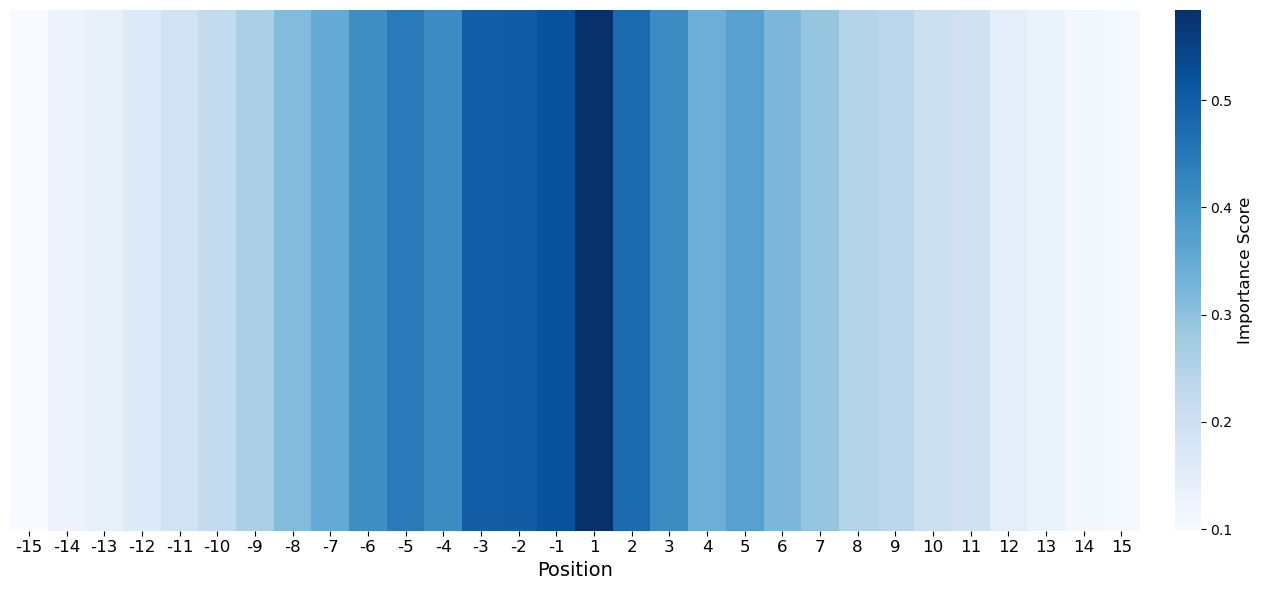

In [103]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(14, 6))
ax = axes
sns.heatmap(data, cmap='Blues', annot=False, cbar_kws={'label': 'Importance Score', 'pad': 0.025})
bar = ax.collections[0].colorbar
bar.ax.yaxis.label.set_fontsize(12)
ax.tick_params(axis='x', labelsize=12)
ax.set_xlabel('Position', fontsize=14)
ax.set_yticklabels('')
plt.yticks([])
plt.tight_layout()
plt.savefig('importance_score.svg', pad_inches=0, bbox_inches='tight')
plt.show()

# Heatmap of integrated gradients (IG) attribution values for amino acids across positions

In [ ]:
preds_idx = preds >= 0.5

In [40]:
attrs = attrs[preds_idx]

In [ ]:
df = pd.read_csv(train_filepath, sep=',', header=0)
train_seqs = df['Sequence']
preds_pos_seqs = train_seqs[preds_idx]

In [ ]:
protein_test_1 = protein_bert_train[preds_idx]
one_hot_test_1 = one_hot_train[preds_idx]
BLOSUM62_test_1 = BLOSUM62_train[preds_idx]

In [ ]:
from collections import defaultdict
ALL_AAS = 'ACDEFGHIKLMNPQRSTVWY'
def index_of_specific_amino(position, seqs):
    indexs = {key : list() for key in ALL_AAS}
    for index, seq in enumerate(seqs):
        absolute_posi = 15 + position
        indexs[seq[absolute_posi]].append(index)
    return indexs

In [47]:
# 计算特定位置区域的积分梯度
def calculate_scores_by_position(start, end, attrs, seqs):
    attr_groups = defaultdict(list)
    for position in range(start, end + 1):
        # 对样本按position位置进行归类
        indexs = index_of_specific_amino(position, seqs)
        # 按类别计算贡献值、重要性
        for key in indexs.keys():
            index = indexs[key]
            category_mean = np.mean(attrs[index], axis=1)
            values = category_mean[:, position + 15]
            values = values.flatten().tolist()
            attr_groups[(position, key)] = values
    return attr_groups

In [48]:
attr_groups = calculate_scores_by_position(-15, 15, attrs, preds_pos_seqs)

## significance test, H0:=0，H1：!=0

In [66]:
from scipy import stats

# 存储结果
results = []

for (pos, aa), values in attr_groups.items():
    if len(values) < 5:  # 样本太少，跳过（避免假阳性）
        continue
    
    # 单样本 t 检验：检验均值是否显著 ≠ 0
    mean_attr = np.mean(np.abs(values))
    std_attr = np.std(values)
    n = len(values)
    t_stat, p_val = stats.ttest_1samp(values, popmean=0.0)
    results.append({
        'position': pos,
        'amino_acid': aa,
        'mean_attr': mean_attr,
        'std_attr': std_attr,
        'n_samples': n,
        'p_value': p_val,
        't_stat': t_stat
    })

In [67]:
import pandas as pd
from statsmodels.stats.multitest import multipletests

df = pd.DataFrame(results)

# FDR 校正（控制错误发现率）
reject, pvals_corrected, _, _ = multipletests(
    df['p_value'], 
    alpha=0.01, 
    method='fdr_bh'
)

In [68]:
df['p_adj'] = pvals_corrected
df['significant'] = df['p_adj'] < 0.01  # True/False

In [71]:
pos_range = np.arange(-15, 16)
aa_list = list("ACDEFGHIKLMNPQRSTVWY")

In [72]:
sig_attr_matrix = np.full((31, 20), np.nan)

for _, row in df.iterrows():
    if row['significant']:
        pos_idx = list(pos_range).index(row['position'])
        aa_idx = aa_list.index(row['amino_acid'])
        sig_attr_matrix[pos_idx, aa_idx] = row['mean_attr']

sig_df = pd.DataFrame(sig_attr_matrix, index=pos_range, columns=aa_list)

In [73]:
index = [i for i in range(-15, 16)]

In [74]:
sig_df = sig_df.loc[index, :]

In [79]:
sig_df = sig_df.T

In [80]:
columns = sig_df.columns.tolist()
columns.remove(0)
sig_df = sig_df[columns]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    sig_df, 
    cmap="coolwarm", 
    center=0,
    annot=False,
    cbar_kws={'label': 'IG Attribution Score'}
)

bar = ax.collections[0].colorbar

bar.ax.yaxis.label.set_fontsize(12)
ax.tick_params(axis='y', which='major', labelsize=9)
ax.tick_params(axis='x', which='major', labelsize=9)
ax.set_ylabel('Amino Acid', fontsize=12)
ax.set_xlabel('Relative Position', fontsize=12)
plt.savefig('Figure of IG score.svg', pad_inches=0, bbox_inches='tight')
plt.show()


KeyboardInterrupt



# motif analysis

In [225]:
df = pd.read_csv(train_filepath, sep=',', header=0)
train_seqs = df['Sequence']
preds_pos_seqs = train_seqs[preds_idx]

1        AGAVKANNSMSKKLMKSDKKIAVISTKLFTE
2        VKANNSMSKKLMKSDKKIAVISTKLFTEKQR
3        QDAFRALQKLSSGSYKIGSKVIKIAWALNKG
5        EIELQSQLSKKAALEKSLEDTKNRYCGQLQM
6        FGEPWKLITKDLVQEKYLEYKQVPSSDPPRF
                      ...               
13919    FHNLMMSDKKSERFFKVLHDRMKRAQQETKS
13922    SQFFFTLGRADELNNKHTIFGKVTGDTVYNM
13923    ECSIQHCLYQFTRNEKLRDANKLLCEVCTRR
13926    DTELQEKETPTQVYQKDKQDADRPLSKMNRA
13931    RVLENLKQQLEEQEYKLQKEQNLNMQLFSEI
Name: Sequence, Length: 7161, dtype: object

In [227]:
def search_sequence_by_motif(seqs, motif):
    indexs = []
    pos = range(-10, 11)
    motif = list(motif)
    motif_new = []
    for i in motif:
        if i != '_':
            motif_new.append(i)
    for index, seq in enumerate(seqs):
        if match_motif(seq, motif_new, pos):
            indexs.append(index)
    return indexs

def match_motif(seq, motif, pos):
    seq = list(seq)
    seq = seq[5:26]
    flag = True
    for i, a in enumerate(seq):
        if motif[i] == 'x':
            continue
        else:
            if motif[i] != seq[i]:
                return False
    return True

In [663]:
motifs= [
         'xxxxxxxxxE_K_xxxxxKxxxx', 
         'xxxxxxxxxx_K_ExxxKxxxxx', 
         'xxxxxKxxxE_K_xxxxxxxxxx',
        ]

In [664]:
d = {}
for motif in motifs:
    indexs = search_sequence_by_motif(preds_pos_seqs, motif)
    d[motif] = indexs

In [672]:
a = set(d['xxxxxKxxxE_K_xxxxxxxxxx'])

In [673]:
sub_attrs = attrs[list(a)]

In [674]:
c = np.mean(sub_attrs, axis=1)[:, 5:26]

In [675]:
c = np.mean(np.abs(c), axis=0, keepdims=True)

In [676]:
columns = ['K(-5)','x(-4)','x(-3)','x(-2)','E(-1)','K(0)']

In [677]:
c = c[:, 5:11]

In [678]:
data = pd.DataFrame(c, columns=columns)

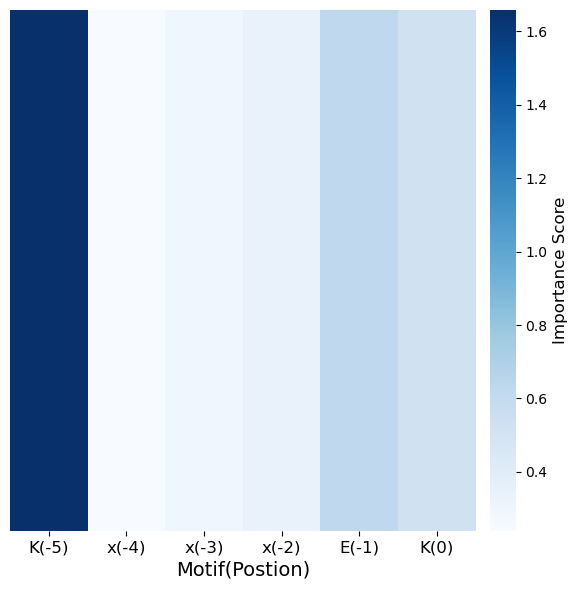

In [679]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = font_prop.get_name()
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

ax = axes
sns.heatmap(data, cmap='Blues', annot=False, cbar_kws={'label': 'Importance Score', 'pad': 0.025})
bar = ax.collections[0].colorbar
bar.ax.yaxis.label.set_fontsize(12)
ax.tick_params(axis='x', labelsize=12)
ax.set_xlabel('Motif(Postion)', fontsize=14)
ax.set_yticklabels('')
plt.yticks([])
plt.tight_layout()
plt.savefig('importance_score_xxxxxKxxxE_K_xxxxxxxxxx.svg', pad_inches=0, bbox_inches='tight')
plt.show()